#Bioacoustics AIMS 2025

#Instructions on how to use this notebook
This notebook is hosted on ``Google Colab``. To be able to work on it, you have to create your own copy. Go to *File* and select *Save a copy in Drive*.

You can also avoid using ``Colab`` entirely, and download the notebook to run it on your own machine. If you choose this, go to *File* and select *Download .ipynb*.

In [132]:
#Run this cell
!pip install git+https://github.com/google-research/perch-hoplite.git

  Cloning https://github.com/google-research/perch-hoplite.git to /tmp/pip-req-build-yhkdyduo
  Running command git clone --filter=blob:none --quiet https://github.com/google-research/perch-hoplite.git /tmp/pip-req-build-yhkdyduo
  Resolved https://github.com/google-research/perch-hoplite.git to commit b075df9dfe2eedbaebfd3e97a52b4cffe3569fe2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Building a Dataset

We will be using [PowderMill Annotated Dataset](https://zenodo.org/records/4656848#.Y7ijhOxudhE) for this Lab. This dataset has been uploaded to Google Cloud Storage for easier access.

In [133]:
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import IPython
import io
from IPython.display import display as ipy
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import collections

from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve, auc

In [134]:
#Run this cell to load the Powdermill dataset and its annotations from Google Cloud Storage
from etils import epath
rec_path = epath.Path('gs://chirp-public-bucket/soundscapes/powdermill/Recording_2')
annos_path = epath.Path('gs://chirp-public-bucket/soundscapes/powdermill/powdermill.csv')

# These epath.Path objects let us interact with the files in Google Cloud
# Storage without having to download them first.

# Some useful methods+tricks:
for fp in rec_path.iterdir():
  #print(fp)
  pass


# Opening a file:
with annos_path.open() as f:
    for i in range(5):
        print(f.readline().strip())


# Iterate over files ending in '.wav':
for fp in rec_path.glob('*.wav'):
    print("Opening:", fp)
    with fp.open('rb') as f:   # 'rb' = read binary (for audio)
        wav_bytes = f.read()



Selection,View,Channel,Begin Time (s),End Time (s),High Freq (Hz),Low Freq (Hz),Species,Filename
1,Spectrogram 1,1,154.387792767,154.911598217,2878.2,4049.0,EATO,Recording_1/Recording_1_Segment_02.wav
2,Spectrogram 1,1,167.526598245,168.17302044,2731.9,3902.7,EATO,Recording_1/Recording_1_Segment_02.wav
3,Spectrogram 1,1,183.609636834,184.097751553,2878.2,3975.8,EATO,Recording_1/Recording_1_Segment_02.wav
4,Spectrogram 1,1,250.527480604,251.160710509,2756.2,3951.4,EATO,Recording_1/Recording_1_Segment_02.wav
Opening: gs://chirp-public-bucket/soundscapes/powdermill/Recording_2/Recording_2_Segment_01.wav
Opening: gs://chirp-public-bucket/soundscapes/powdermill/Recording_2/Recording_2_Segment_02.wav
Opening: gs://chirp-public-bucket/soundscapes/powdermill/Recording_2/Recording_2_Segment_03.wav
Opening: gs://chirp-public-bucket/soundscapes/powdermill/Recording_2/Recording_2_Segment_04.wav
Opening: gs://chirp-public-bucket/soundscapes/powdermill/Recording_2/Recording_2_Segment_05.wav
Opening:

In [135]:
#YOUR CODE GOES HERE

  # (i) Open each file, create a spectrogram for every 5-second segment within each file.

  # (ii) Put all of the spectrograms in one big array.
  # (iii) Make a second list/dataframe with the source file and start and end time of each spectrogram.


In [136]:
spectrograms = []
metadata = []
#sr = 32_000 #@param
second_duration = 5.0

# (i) Open each file and create spectrograms for every 5-second segment
for fp in rec_path.glob('*.wav'):
    with fp.open('rb') as f:
        audio_bytes = f.read()

    # Load audio
    y, sr = librosa.load(io.BytesIO(audio_bytes), sr=None)
    total_dur = len(y) / sr
    n_segments = int(total_dur // second_duration)

    for i in range(n_segments):
        start_s = i * second_duration
        end_s = start_s + second_duration

        start_idx = int(start_s * sr)
        end_idx = int(end_s * sr)

        segment = y[start_idx:end_idx]

        # Create STFT power spectrogram
        S = np.abs(librosa.stft(segment, n_fft=1024, hop_length=512))**2

        spectrograms.append(S)
        metadata.append({
            "file": str(fp),
            "start_time_s": start_s,
            "end_time_s": end_s,
        })

# (ii) Put all spectrograms in one big array
spectrograms = np.array(spectrograms, dtype= np.float32)

# (iii) Make dataframe of metadata
metadata_df = pd.DataFrame(metadata)

In [137]:

#YOUR CODE GOES HERE

#(i) Read the annotations file and list all species
species_set = set()

with annos_path.open() as f:
    reader = csv.DictReader(f)
    print(f'list of columns : {reader.fieldnames}')
    for row in reader:
        species = row["Species"].strip()
        if species != "":
            species_set.add(species)

species_list = sorted(species_set)
print("Number of species:", len(species_list))
print("Species list:", species_list)


list of columns : ['Selection', 'View', 'Channel', 'Begin Time (s)', 'End Time (s)', 'High Freq (Hz)', 'Low Freq (Hz)', 'Species', 'Filename']
Number of species: 48
Species list: ['AMCR', 'AMGO', 'AMRE', 'AMRO', 'BAOR', 'BAWW', 'BBWA', 'BCCH', 'BGGN', 'BHCO', 'BHVI', 'BLJA', 'BRCR', 'BTNW', 'BWWA', 'CANG', 'CARW', 'CEDW', 'CORA', 'COYE', 'CSWA', 'DOWO', 'EATO', 'EAWP', 'HAWO', 'HETH', 'HOWA', 'KEWA', 'LOWA', 'NAWA', 'NOCA', 'NOFL', 'OVEN', 'PIWO', 'RBGR', 'RBWO', 'RCKI', 'REVI', 'RSHA', 'RWBL', 'SCTA', 'SWTH', 'TUTI', 'VEER', 'WBNU', 'WITU', 'WOTH', 'YBCU']


In [138]:
# Let's work with EATO, which is the Eastern Towhee.
eato_annos = []

#YOUR CODE GOES HERE

#(i) Create an array of EATO labels for each spectrogram in our big tensor.
# Load all EATO annotations
with annos_path.open() as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row["Species"] == "EATO":
            eato_annos.append({
                "file": row["Filename"],
                "start": float(row["Begin Time (s)"]),
                "end": float(row["End Time (s)"])
            })

# Prepare label array (0/1 for each spectrogram)
y_eato_labels = []
#(ii) Check for overlapping annotations with each spectrogram segment:
for idx, row in metadata_df.iterrows():
    seg_file = row["file"].split("/")[-1]   # filename only
    seg_start = row["start_time_s"]
    seg_end = row["end_time_s"]

    label = 0
    for anno in eato_annos:
        anno_file_basename = anno["file"].split("/")[-1]
        if anno_file_basename == seg_file:
            #           anno_start < window_end AND anno_end > window_start
            if anno["start"] < seg_end and anno["end"] > seg_start:
                label = 1
                break

    y_eato_labels.append(label)
# Convert to numpy array
y_eato_labels = np.array(y_eato_labels)

print("EATO labels created. Positive segments:", np.sum(y_eato_labels))


EATO labels created. Positive segments: 284


In [139]:
len(eato_annos)

5238

#Classification

In [140]:
#YOUR CODE GOES HERE

# Next, reduce the spectrograms to single vectors. (How many ways can you think of to do this?)
# Use sklearn.LogisticRegression to train a classifier over your reduced spectrograms.

In [141]:

# YOUR CODE GOES HERE

# Reduce the spectrograms to single vectors by flattening them
#X_features = np.array([s.flatten() for s in spectrograms])
X_features = np.array([s.mean(axis=1) for s in spectrograms])
model = LogisticRegression()


In [142]:
X_train,X_test,y_train, y_test = train_test_split(X_features, y_eato_labels, test_size=0.2, stratify=y_eato_labels)

Accuracy: 0.6786
ROC-AUC : 0.6833
Confusion Matrix:
[[103   8]
 [ 46  11]]


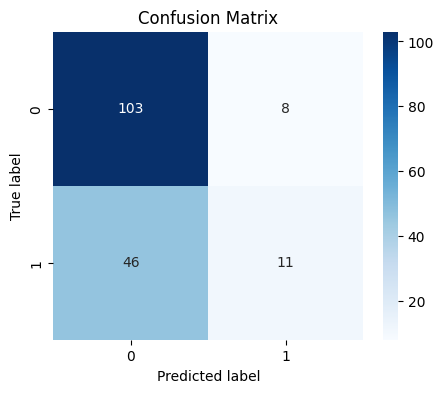

In [143]:
# Train the model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC : {roc_auc:.4f}")
print("Confusion Matrix:")
print(cm)
# Draw the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

In [144]:
#  Train on all data recording 2
model.fit(X_features, y_eato_labels)

LogisticRegression()

In [145]:
#YOUR CODE GOES HERE

# The Powdermill dataset contains four Recordings (Recording_1, Recording_2, etc).
# Refactor your function for loading the spectrograms into an array and loads
# the labels into a function, which takes the Recording directory as input.

# Use the spectrograms and labels from the other Recordings to evaluate your model.
# Compute the ROC-AUC score:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
# (Note: it will proooobably be bad scores.)

In [146]:
def load_eato_annotations(annos_path, species_code="EATO"):
    eato_annos = []
    with annos_path.open() as f:
        reader = csv.DictReader(f)
        for row in reader:
            if row.get("Species", "").strip() == species_code:
                eato_annos.append({
                    "file": row["Filename"],
                    "start": float(row["Begin Time (s)"]),
                    "end": float(row["End Time (s)"])
                })
    return eato_annos

def create_labels(metadata_df, annotations):
    labels = []
    for idx, row in metadata_df.iterrows():
        seg_file = row["file"].split("/")[-1]
        seg_start = row["start_time_s"]
        seg_end = row["end_time_s"]

        label = 0
        for anno in annotations:
            anno_file_basename = anno["file"].split("/")[-1]
            if anno_file_basename == seg_file:
                if anno["start"] < seg_end and anno["end"] > seg_start:
                    label = 1
                    break
        labels.append(label)
    return np.array(labels, dtype=np.int64)

def spectrograms_into_an_array(rec_path_list):
    spectrograms = []
    metadata = []
    for rec_path_str in rec_path_list:
        rec_path = epath.Path(rec_path_str)
        for fp in rec_path.glob('*.wav'):
            with fp.open('rb') as f:
                audio_bytes = f.read()

            # Load audio
            y, sr = librosa.load(io.BytesIO(audio_bytes), sr=None)
            total_dur = len(y) / sr
            n_segments = int(total_dur // second_duration)

            for i in range(n_segments):
                start_s = i * second_duration
                end_s = start_s + second_duration

                start_idx = int(start_s * sr)
                end_idx = int(end_s * sr)

                segment = y[start_idx:end_idx]

                # Create STFT power spectrogram
                S = np.abs(librosa.stft(segment, n_fft=1024, hop_length=512))**2

                spectrograms.append(S)
                metadata.append({
                    "file": str(fp),
                    "start_time_s": start_s,
                    "end_time_s": end_s,
                })
    # (ii) Put all spectrograms in one big array
    spectrograms = np.array(spectrograms, dtype=np.float32)

    # (iii) Make dataframe of metadata
    metadata_df = pd.DataFrame(metadata)
    # Load EATO annotations
    eato_annos = load_eato_annotations(annos_path)

    # Generate label array aligned with your spectrograms / metadata
    labels = create_labels(metadata_df, eato_annos)
    #X_features = np.array([s.flatten() for s in spectrograms])
    X_features = np.array([s.mean(axis=1) for s in spectrograms])
    return X_features, labels


In [147]:
# Let's train
#rec_path_list_train = ['gs://chirp-public-bucket/soundscapes/powdermill/Recording_2']
rec_path_list_evaluate = ['gs://chirp-public-bucket/soundscapes/powdermill/Recording_1',
                      'gs://chirp-public-bucket/soundscapes/powdermill/Recording_3',
                      'gs://chirp-public-bucket/soundscapes/powdermill/Recording_4'
                      ]


In [148]:
X_features_test, labels_test = spectrograms_into_an_array(rec_path_list_evaluate)
y_pred = model.predict(X_features_test)

accuracy = accuracy_score(labels_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
y_proba_test = model.predict_proba(X_features_test)[:, 1]
auc_test = roc_auc_score(labels_test, y_proba_test)
print(f"ROC-AUC for Recording_1_3_4: {auc_test:.4f}")

Accuracy: 0.1981
ROC-AUC for Recording_1_3_4: 0.4290


Accuracy for Recording_1_3_4: 0.1981
Confusion Matrix for Recording_1_3_4:
[[ 413  102]
 [2929  336]]


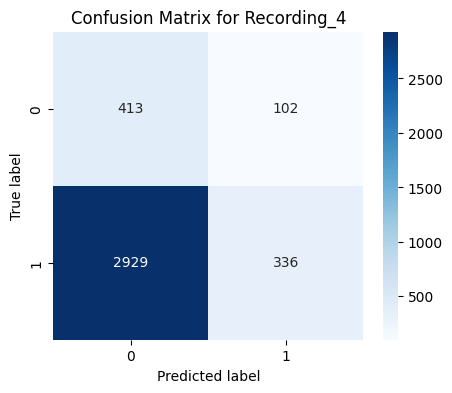

In [149]:
y_pred_test = model.predict(X_features_test)

cm_test = confusion_matrix(labels_test, y_pred_test)

accuracy_test = accuracy_score(labels_test, y_pred_test)
print(f"Accuracy for Recording_1_3_4: {accuracy_test:.4f}")
print("Confusion Matrix for Recording_1_3_4:")
print(cm_test)
# Draw the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix for Recording_4')
plt.show()

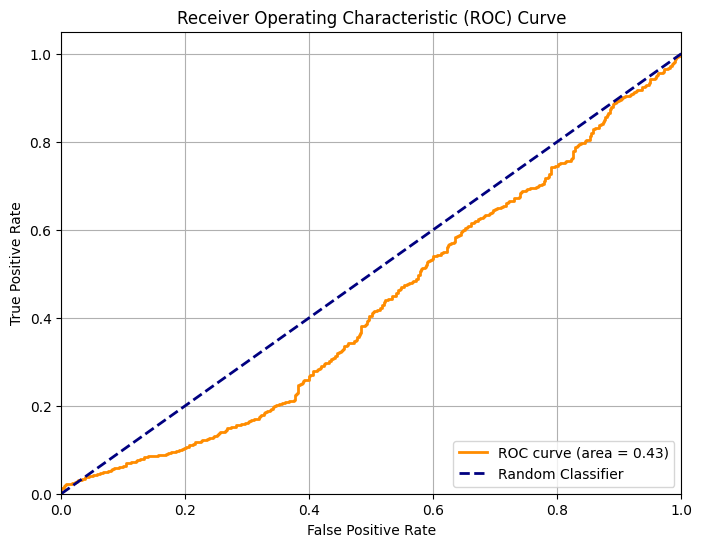

In [150]:

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(labels_test, y_proba_test)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [151]:
#YOUR CODE GOES HERE

# Extension if you find yourself done early!
# Use T-SNE to reduce your 'single vectors' to two dimensions:
# https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html
# Use matplot lib's `scatter` to plot the points, and color them according to
# the EATO label.

# If you finish this, shout!

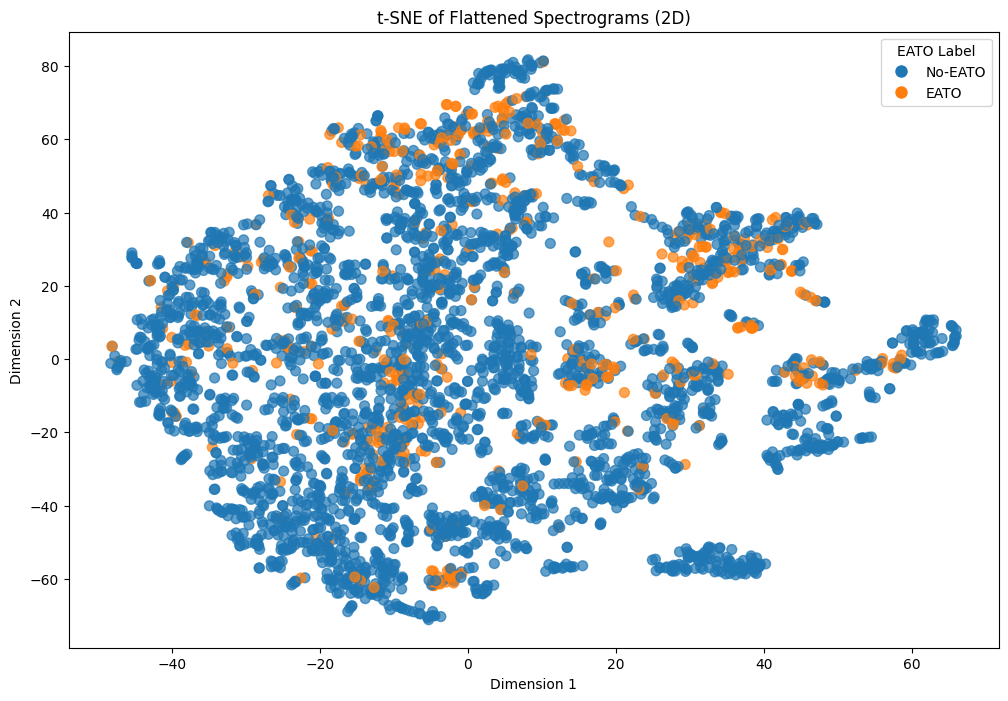

In [168]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_2d = tsne.fit_transform(X_features_test)

# Colors
colors = ['tab:orange' if l == 0 else 'tab:blue' for l in labels_test]

# Plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=colors,
    alpha=0.7,
    s=50
)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='No-EATO', markerfacecolor='tab:blue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='EATO', markerfacecolor='tab:orange', markersize=10)
]
plt.legend(handles=legend_elements, title="EATO Label")

plt.title("t-SNE of Flattened Spectrograms (2D)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

**NB:** I trained my model on Recording 2. As the exercise requires, I then evaluated it on the other recordings (I chose 1, 3, and 4). Initially, I split Recording 2 into training and test sets to check the model’s precision. Once I was satisfied with the results, I retrained the model on all of Recording 2 and used it to evaluate performance on the other recordings.